In [1]:
import pandas as pd
from Bio import SeqIO
import csv
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy
from scipy import stats

import plotting_utils as plot_utils

### Load FASTA and GFF3

In [2]:
# GFF3 from Ensembl Genomes
gff_file = "../dependencies/Homo_sapiens.GRCh38.114.gff3"
# hg38 fasta from UCSC
fasta_file = "../dependencies/GRCh38.p14.genome.fa"

In [3]:
fasta_index = SeqIO.to_dict(SeqIO.parse(fasta_file, "fasta"))

In [4]:
def get_sequence(chrom, start, end, strand):
    seq = fasta_index[chrom].seq[start-1:end]
    if strand == '-':
        seq = seq.reverse_complement()
    return str(seq)

In [5]:
def load_gff_preserve_attributes(gff_file):
    return pd.read_csv(
        gff_file,
        sep="\t",
        comment="#",
        header=None,
        dtype=str,
        quoting=csv.QUOTE_NONE,
        names=[
            "seqid", "source", "type", "start", "end", "score",
            "strand", "phase", "attributes"
        ],
    )

In [6]:
def extract_attr(attr_str, key):
    # Extracts a single attribute from GFF attributes column
    for part in attr_str.split(";"):
        if part.startswith(key + "="):
            return part.split("=", 1)[1]
    return None
    
def parse_attributes(df):
    for k in ["ID", "Parent", "biotype", "tag"]:
        df[k] = df["attributes"].apply(lambda x: extract_attr(x, k))
        
    df["ID_stripped"] = df["ID"].fillna("").str.split(":", n=1).str[-1]
    df["Parent_stripped"] = df["Parent"].fillna("").str.split(":", n=1).str[-1]
    
    return df

In [7]:
gff = load_gff_preserve_attributes(gff_file)
gff = parse_attributes(gff)

gff["start"] = gff["start"].astype(int)
gff["end"] = gff["end"].astype(int)

#### Filter to chromosomes only

In [8]:
def is_chromosome(seqid):
    return bool(re.match(r'^(chr)?([1-9]|1[0-9]|2[0-2]|X|Y)$', str(seqid)))

def prepend_chr(seqid):
    seqid = str(seqid)
    return seqid if seqid.startswith("chr") else f"chr{seqid}"

In [9]:
# Filter to chr only
gff_chr_df = gff[gff["seqid"].apply(is_chromosome)].copy()

# UCSC FASTA has chr<...> format, so edit the GFF df to also include the chr prefix
gff_chr_df["seqid"] = gff_chr_df["seqid"].apply(prepend_chr)

In [10]:
gff_chr_df["transcript_support_level"] = gff_chr_df["attributes"].apply(lambda x: extract_attr(x, "transcript_support_level"))
tx_to_gene = gff_chr_df[gff_chr_df["type"].isin(["transcript", "mRNA"])][
    ["ID_stripped", "Parent_stripped", "biotype", "transcript_support_level"]
].rename(columns={
    "ID_stripped": "transcript_id",
    "Parent_stripped": "gene_id",
    "biotype": "transcript_biotype",
})

In [11]:
lncRNA_tx_to_gene = gff_chr_df[gff_chr_df["type"].isin(["lnc_RNA"])][
    ["ID_stripped", "Parent_stripped", "biotype", "transcript_support_level"]
].rename(columns={
    "ID_stripped": "transcript_id",
    "Parent_stripped": "gene_id",
    "biotype": "transcript_biotype",
})

#### Filter to Protein-Coding Transcripts

In [20]:
# List of protein coding genes (type == gene and biotype == protein_coding)
protein_coding_gene_ids = gff_chr_df[
    (gff_chr_df["type"] == "gene") &
    (gff_chr_df["biotype"] == "protein_coding")
]["ID_stripped"].unique().tolist()

# Transcripts for protein coding genes
protein_coding_gene_transcripts = gff_chr_df[
    (gff_chr_df["type"] == "mRNA") &
    (gff_chr_df["Parent_stripped"].isin(protein_coding_gene_ids))
]["ID_stripped"].unique().tolist()

# Take only intron-containing transcripts
exon_counts = gff_chr_df[
    (gff_chr_df["type"] == "exon") &
    (gff_chr_df["Parent_stripped"].isin(protein_coding_gene_transcripts))
].groupby("Parent_stripped").size()

multi_exon_tx_ids = set(exon_counts[exon_counts > 1].index.tolist())

# Filter to TSL1 only transcripts:
# tsl1 – all splice junctions of the transcript are supported by at least one non-suspect mRNA
tsl_one = set(tx_to_gene.loc[tx_to_gene["transcript_support_level"].apply(lambda x: x is not None and str(x)[0] == "1")]["transcript_id"].tolist())
multi_exon_tsl_one_tx_ids = multi_exon_tx_ids & tsl_one

# MANE Select
mane_select_transcripts = \
    set(gff_chr_df.loc[gff_chr_df["tag"].apply(lambda x: x is not None and "MANE_Select" in str(x))]["ID_stripped"].tolist())
multi_exon_mane_select_tx_id = multi_exon_tx_ids & mane_select_transcripts

# Get all transcripts (and their child features and parent genes) 
# in the intron-containing, protein-coding subset
protein_coding_subset = gff_chr_df[
    (gff_chr_df["ID_stripped"].isin(protein_coding_gene_ids)) |
    (gff_chr_df["ID_stripped"].isin(multi_exon_tsl_one_tx_ids)) |
    (gff_chr_df["Parent_stripped"].isin(multi_exon_mane_select_tx_id))
]

#### Filter to lncRNA Transcripts

In [22]:
for level in range(1, 6):
    print(f"TSL{level}", gff_chr_df[
        (gff_chr_df["type"] == "lnc_RNA") &
        (gff_chr_df["biotype"] == "lncRNA")
    ]["transcript_support_level"].apply(lambda x: x is not None and str(x).startswith(str(level))).sum())

TSL1 3117
TSL2 5093
TSL3 7448
TSL4 2685
TSL5 7008


In [23]:
# List of lncRNA genes
lncRNA_gene_ids = gff_chr_df[
    (gff_chr_df["type"] == "ncRNA_gene") &
    (gff_chr_df["biotype"] == "lncRNA")
]["ID_stripped"].unique().tolist()

# Transcripts for lncRNA genes
lncRNA_gene_transcripts = gff_chr_df[
    (gff_chr_df["type"] == "lnc_RNA") &
    (gff_chr_df["Parent_stripped"].isin(lncRNA_gene_ids))
]["ID_stripped"].unique().tolist()

# Take only intron-containing transcripts
lncRNA_exon_counts = gff_chr_df[
    (gff_chr_df["type"] == "exon") &
    (gff_chr_df["Parent_stripped"].isin(lncRNA_gene_transcripts))
].groupby("Parent_stripped").size()

lncRNA_multi_exon_tx_ids = set(lncRNA_exon_counts[lncRNA_exon_counts > 1].index.tolist())

# Filter to TSL1 only transcripts:
# tsl1 – all splice junctions of the transcript are supported by at least one non-suspect mRNA
lncRNA_tsl_one = set(lncRNA_tx_to_gene.loc[lncRNA_tx_to_gene["transcript_support_level"].apply(lambda x: x is not None and str(x)[0] == "1")]["transcript_id"].tolist())
lncRNA_multi_exon_tsl_one_tx_ids = lncRNA_multi_exon_tx_ids & lncRNA_tsl_one

# Get all transcripts (and their child features and parent genes) 
# in the intron-containing, protein-coding subset
lncRNA_subset = gff_chr_df[
    (gff_chr_df["ID_stripped"].isin(lncRNA_gene_ids)) |
    (gff_chr_df["ID_stripped"].isin(lncRNA_multi_exon_tsl_one_tx_ids)) |
    (gff_chr_df["Parent_stripped"].isin(lncRNA_multi_exon_tsl_one_tx_ids))
]

### Identify Exons

In [24]:
cds_df = protein_coding_subset[protein_coding_subset["type"] == "CDS"].copy()
exons_df = protein_coding_subset[protein_coding_subset["type"] == "exon"].copy()
lncRNA_exons_df = lncRNA_subset[lncRNA_subset["type"] == "exon"].copy()

In [25]:
# Add exon metadata
for df in [exons_df, lncRNA_exons_df]:
    df["ID"] = df["attributes"].apply(lambda x: extract_attr(x, "exon_id"))
    df["exon_rank"] = df["attributes"].apply(lambda x: int(extract_attr(x, "rank")))
    df["exon_constitutive"] = df["attributes"].apply(lambda x: int(extract_attr(x, "constitutive")))
    last_exon_rank = df.groupby("Parent_stripped")["exon_rank"].transform("max")
    df["exon_count"] = last_exon_rank
    
    df["internal_exon"] = df.apply(
        lambda r: r["exon_rank"] != 1 and r["exon_rank"] != r["exon_count"], 
        axis=1
    )

In [26]:
# Add gene IDs using transcript -> gene map
exons_df = exons_df.merge(
    tx_to_gene, 
    left_on="Parent_stripped",
    right_on="transcript_id",
    how="left"
)

# Add CDS metadata
cds_df["ID"] = cds_df["attributes"].apply(lambda x: extract_attr(x, "ID"))

# Calculate CDS rank
cds_df = cds_df.sort_values(
    by=["Parent_stripped", "start", "end"],
    ascending=[True, True, True]
)
cds_df["cds_rank"] = cds_df.groupby("Parent_stripped").cumcount() + 1
cds_df["cds_count"] = cds_df.groupby("Parent_stripped")["cds_rank"].transform("max")

# For negative strand, reverse the ranking within each transcript
negative_strand_mask = cds_df["strand"] == "-"
cds_df.loc[negative_strand_mask, "cds_rank"] = (
    cds_df.loc[negative_strand_mask, "cds_count"] -
    cds_df.loc[negative_strand_mask, "cds_rank"] + 1
)

cds_df = cds_df.merge(
    tx_to_gene, 
    left_on="Parent_stripped",
    right_on="transcript_id",
    how="left"
)

In [27]:
def find_stop_codons_in_sequence(sequence, exon_start, exon_end, strand):
    """
    Find stop codons in a DNA sequence in all three reading frames.
    Returns count and genomic/relative positions of stop codons.
    """
    stop_codons = {"TAA", "TAG", "TGA"}
    stop_codon_info = []
    exon_length = len(sequence)
    
    # Search in all three reading frames
    for frame in range(3):
        for i in range(frame, len(sequence) - 2, 3):
            codon = sequence[i:i+3].upper()
            if codon in stop_codons:
                # Calculate genomic position based on strand
                if strand == "+":
                    genomic_pos = exon_start + i
                else:
                    genomic_pos = exon_end - i
                
                # Calculate reading frame based on position (assuming phase 0)
                reading_frame = i % 3
                
                stop_codon_info.append({
                    "genomic_position": genomic_pos,
                    "codon": codon,
                    "frame": frame,
                    "reading_frame": reading_frame,
                    "position_from_start": i,
                    "position_from_end": exon_length - i - 1
                })
    
    return {
        "has_stop_codon": len(stop_codon_info) > 0,
        "stop_codon_count": len(stop_codon_info),
        "stop_codon_genomic_positions": [info["genomic_position"] for info in stop_codon_info],
        "stop_codon_types": [info["codon"] for info in stop_codon_info],
        "stop_codon_reading_frames": [info["reading_frame"] for info in stop_codon_info],
        "stop_codon_positions_from_start": [info["position_from_start"] for info in stop_codon_info],
        "stop_codon_positions_from_end": [info["position_from_end"] for info in stop_codon_info]
    }

def analyze_stop_codons_with_positions(row):
    """Analyze stop codons with genomic and relative positions."""
    sequence = get_sequence(row["seqid"], row["start"], row["end"], row["strand"])
    return find_stop_codons_in_sequence(sequence, row["start"], row["end"], row["strand"])

In [28]:
stop_codon_exons = exons_df.apply(analyze_stop_codons_with_positions, axis=1)
exons_df["has_stop_codon"] = stop_codon_exons.apply(lambda x: x["has_stop_codon"])
exons_df["stop_codon_count"] = stop_codon_exons.apply(lambda x: x["stop_codon_count"])
exons_df["stop_codon_genomic_positions"] = stop_codon_exons.apply(lambda x: x["stop_codon_genomic_positions"])
exons_df["stop_codon_types"] = stop_codon_exons.apply(lambda x: x["stop_codon_types"])

cds_stop_codon_results = cds_df.apply(analyze_stop_codons_with_positions, axis=1)
cds_df["has_stop_codon_cds"] = cds_stop_codon_results.apply(lambda x: x["has_stop_codon"])

In [29]:
# Join on transcript, chromosome, and strand, then filter for CDS contained within exon
exons_with_cds = exons_df.merge(
    cds_df[[
        "seqid", "start", "end", "strand", "Parent_stripped",
        "cds_rank", "cds_count", "has_stop_codon_cds",
    ]],
    left_on=["seqid", "Parent_stripped", "strand"],
    right_on=["seqid", "Parent_stripped", "strand"],
    how="left",
    suffixes=("_exon", "_cds"),
)

# Filter to keep only rows where CDS is contained within the exon
exons_with_cds = exons_with_cds[
    (exons_with_cds["start_cds"] >= exons_with_cds["start_exon"]) &
    (exons_with_cds["end_cds"] <= exons_with_cds["end_exon"])
]

# Fill NaN values for exons without CDS
exons_with_cds["has_stop_codon_cds"] = exons_with_cds["has_stop_codon_cds"].fillna(False)

In [30]:
grouped_exons_with_cds = exons_with_cds \
      .groupby(["seqid", "type", "start_exon", "end_exon", "strand",
               "has_stop_codon", "stop_codon_count"]) \
      .agg({
          "ID": list,
          "Parent_stripped": list,
          "gene_id": list,
          "exon_rank": list,
          "exon_count": list,
          "exon_constitutive": list,
          "internal_exon": list,
          "start_cds": list,
          "end_cds": list,
          "cds_rank": list,
          "cds_count": list,
          "has_stop_codon_cds": list,
          "stop_codon_genomic_positions": "first",
          "stop_codon_types": "first",
      }) \
     .reset_index(drop=False)

In [31]:
grouped_exons_with_cds["first_exon_rank"] = grouped_exons_with_cds["exon_rank"].apply(lambda x: int(min(x)))

In [32]:
grouped_exons_with_cds["exon_length"] = grouped_exons_with_cds["end_exon"] - grouped_exons_with_cds["start_exon"] + 1

### Add Splicing Predictions

In [33]:
splicing_predictions = pd.read_csv("../data/Homo_sapiens.GRCh38.114.protein_coding.exons.SplicePredictions.csv.gz")

In [34]:
# Merge exon data with SpliceAI scores
exons_with_cds_scored = pd.merge(
    grouped_exons_with_cds,
    splicing_predictions,
    how="inner",
    left_on=["seqid", "start_exon", "end_exon", "strand"],
    right_on=["seqid", "start", "end", "strand"],
    suffixes=("_exon", "_scores"),
    validate="1:1"
)

In [35]:
# Add columns with display names
col_map = {
    "SpliceAI Acceptor": "spliceai_acceptor_avg",
    "SpliceAI Donor": "spliceai_donor_avg",
    "SpliceAI\nAcceptor": "spliceai_acceptor_avg",
    "SpliceAI\nDonor": "spliceai_donor_avg",
    "AlphaGenome p(Acceptor)": "alphagenome_p_acceptor",
    "AlphaGenome p(Donor)": "alphagenome_p_donor",
    "AlphaGenome\np(Acceptor)": "alphagenome_p_acceptor",
    "AlphaGenome\np(Donor)": "alphagenome_p_donor",
    "Pangolin p(Acceptor)": "pangolin_average_psplice_acceptor",
    "Pangolin p(Donor)": "pangolin_average_psplice_donor",
    "Pangolin\np(Acceptor)": "pangolin_average_psplice_acceptor",
    "Pangolin\np(Donor)": "pangolin_average_psplice_donor",
    "Pangolin Acceptor Usage": "pangolin_average_usage_acceptor",
    "Pangolin Donor Usage": "pangolin_average_usage_donor",
    "Pangolin\nAcceptor Usage": "pangolin_average_usage_acceptor",
    "Pangolin\nDonor Usage": "pangolin_average_usage_donor",
}

for new_col, source_col in col_map.items():
    exons_with_cds_scored[new_col] = exons_with_cds_scored[source_col]

In [36]:
# Internal
internal_exons_with_cds_scored = exons_with_cds_scored[exons_with_cds_scored["internal_exon"].apply(lambda x: any(x))]

# Has stop codon in CDS
internal_exons_with_cds_scored_stop = internal_exons_with_cds_scored[internal_exons_with_cds_scored["has_stop_codon_cds"].apply(any)]
# Last coding exon
internal_last_cds_exons_scored = internal_exons_with_cds_scored_stop[internal_exons_with_cds_scored_stop.apply(
    lambda r: any(count == rank for count, rank in zip(r["cds_count"], r["cds_rank"])), axis=1
)]
last_exons_list = internal_last_cds_exons_scored.apply(lambda r: f"{r.seqid}_{r.start_exon}_{r.end_exon}_{r.strand}", axis=1).tolist()

In [37]:
internal_exons_with_cds_scored_last = internal_exons_with_cds_scored.loc[
    internal_exons_with_cds_scored.apply(lambda r: f"{r.seqid}_{r.start_exon}_{r.end_exon}_{r.strand}", axis=1).isin(last_exons_list)
]
internal_exons_with_cds_scored_notlast = internal_exons_with_cds_scored.loc[
    ~internal_exons_with_cds_scored.apply(lambda r: f"{r.seqid}_{r.start_exon}_{r.end_exon}_{r.strand}", axis=1).isin(last_exons_list)
]

In [38]:
internal_exons_with_cds_scored_last_constitutive = internal_exons_with_cds_scored_last[internal_exons_with_cds_scored_last.apply(
     lambda r: any(r["exon_constitutive"]), axis=1
)]
internal_exons_with_cds_scored_notlast_constitutive = internal_exons_with_cds_scored_notlast[internal_exons_with_cds_scored_notlast.apply(
     lambda r: any(r["exon_constitutive"]), axis=1
)]

### Final Internal Coding Exon vs Other Exons

In [39]:
cols_to_test = [
    "SpliceAI Acceptor",
    "SpliceAI Donor",
    "AlphaGenome p(Donor)",
    "AlphaGenome p(Acceptor)",
    "Pangolin p(Acceptor)",
    "Pangolin p(Donor)",
    "Pangolin Acceptor Usage",
    "Pangolin Donor Usage",
]

# Loop through columns and print the t-test results
for col in cols_to_test:
    t_stat, p_val = scipy.stats.ttest_ind(
        internal_exons_with_cds_scored_last[col],
        internal_exons_with_cds_scored_notlast[col],
        equal_var=False
    )
    print(f"{col}: t = {t_stat:.4f}, p = {p_val:.4e}")

SpliceAI Acceptor: t = -12.7279, p = 6.7729e-34
SpliceAI Donor: t = -14.6955, p = 2.0912e-43
AlphaGenome p(Donor): t = -11.7289, p = 2.1070e-29
AlphaGenome p(Acceptor): t = -9.1569, p = 4.4802e-19
Pangolin p(Acceptor): t = -19.8894, p = 9.4299e-72
Pangolin p(Donor): t = -18.9424, p = 2.6192e-66
Pangolin Acceptor Usage: t = -24.5836, p = 1.0643e-99
Pangolin Donor Usage: t = -23.9181, p = 1.2606e-95


In [40]:
def plot_boxplot_two_dfs(
    df1, df2, columns, labels,
    fontsize=8, dpi=300, figsize=(6,3), bbox_to_anchor=(0.5, -0.45)
):
    df1_long = df1[columns].melt(var_name="Type", value_name="Score")
    df1_long["Dataset"] = labels[0]
    df2_long = df2[columns].melt(var_name="Type", value_name="Score")
    df2_long["Dataset"] = labels[1]    
    df_long = pd.concat([df1_long, df2_long], ignore_index=True)

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    sns.boxplot(
        data=df_long,
        x="Type",
        y="Score",
        hue="Dataset",
        palette=["tab:blue", "tab:orange"],
        fliersize=0,
        ax=ax
    )

    legend_counts = df_long.groupby("Dataset").size().to_dict()
    new_labels = [f"{lab} (n={legend_counts[lab] // len(columns)})" for lab in labels]

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles, labels=new_labels, title="", ncol=1, 
        loc="lower center", bbox_to_anchor=bbox_to_anchor, 
        fontsize=fontsize, title_fontsize=fontsize
    )
    
    ax.tick_params(axis='x', rotation=0, labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.set_ylabel("")
    ax.set_xlabel("")

    return fig, ax

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/651361419.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


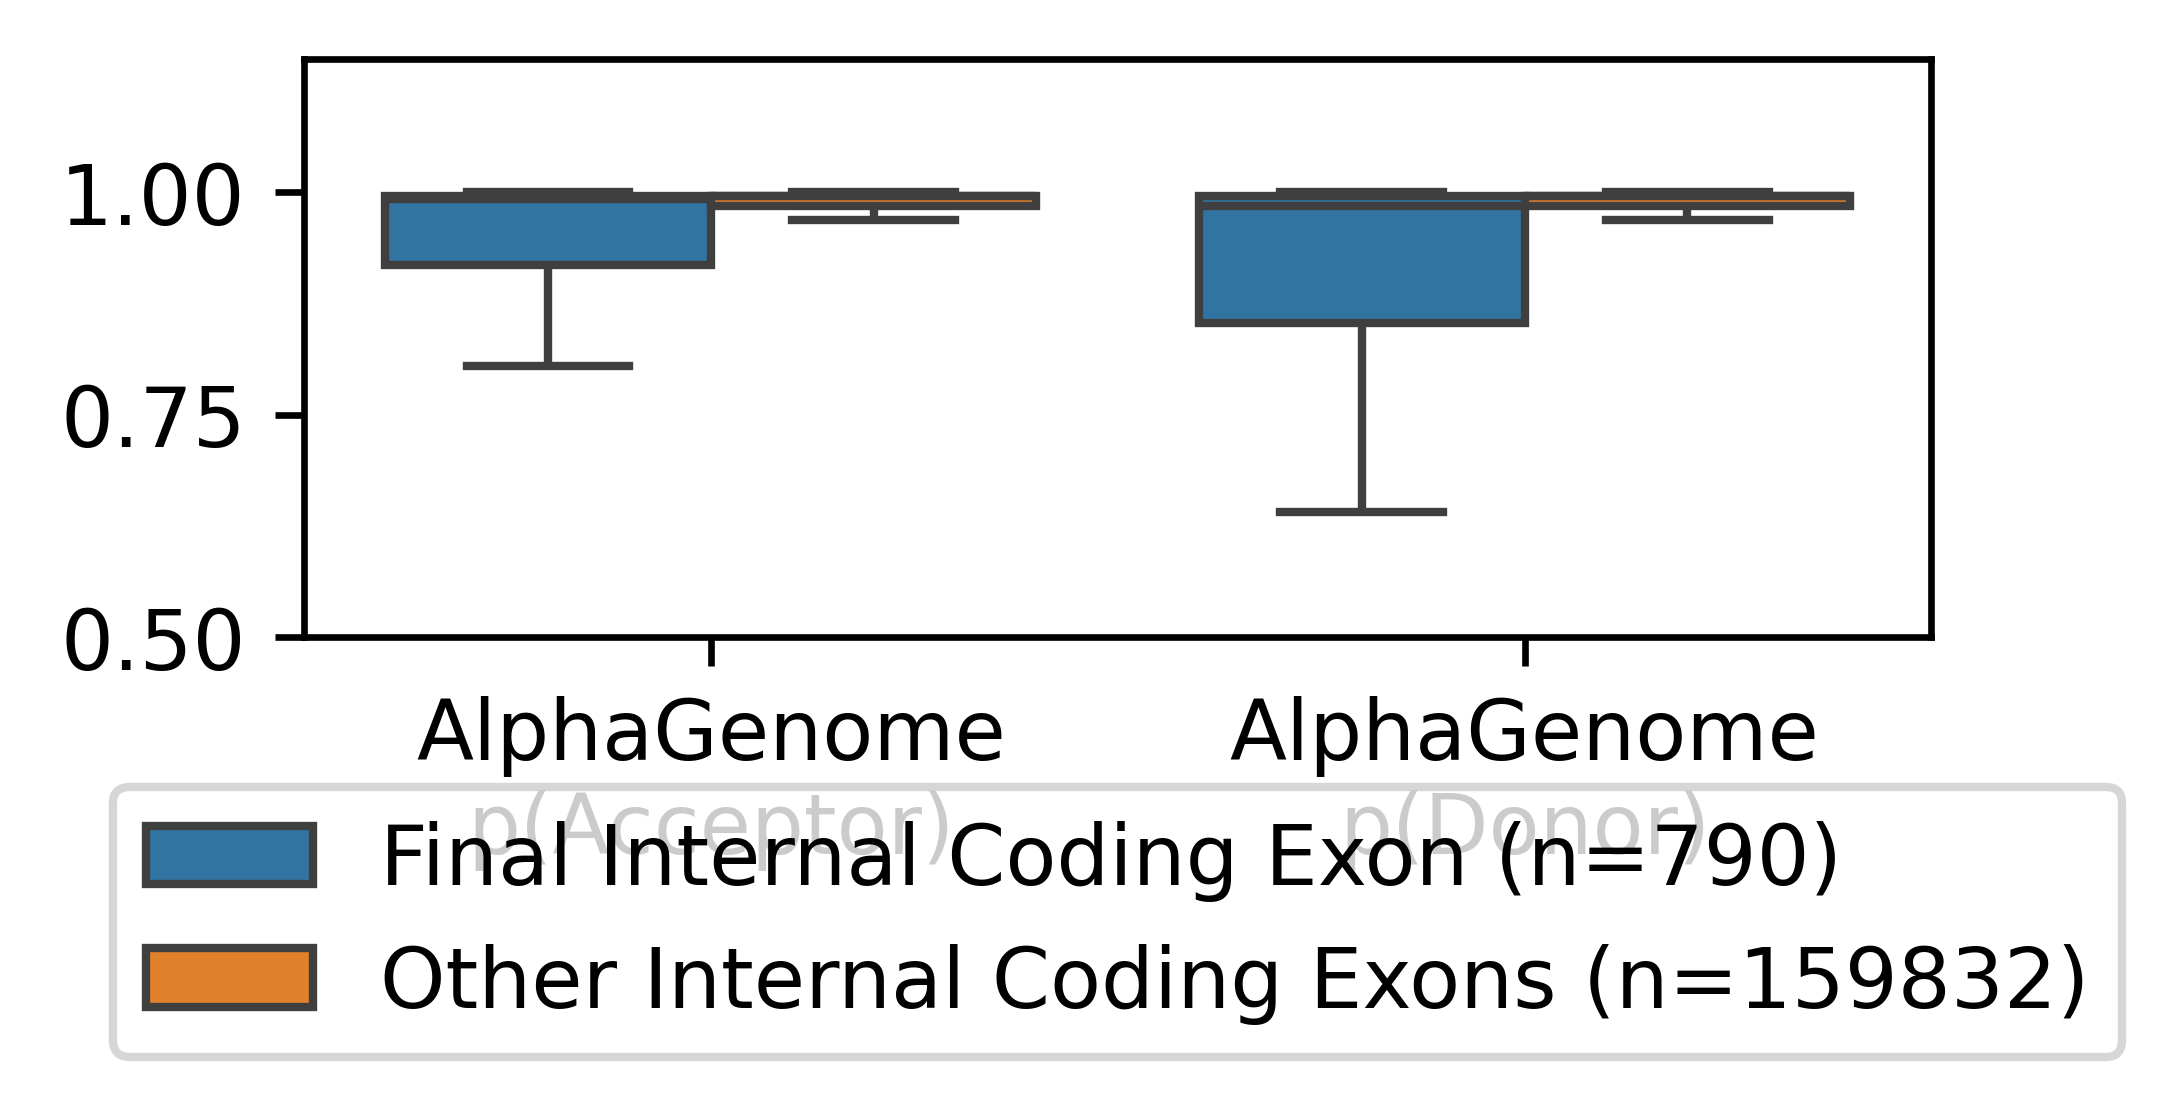

In [41]:
fig, ax = plot_boxplot_two_dfs(
    internal_exons_with_cds_scored_last, 
    internal_exons_with_cds_scored_notlast, 
    columns=["AlphaGenome\np(Acceptor)", "AlphaGenome\np(Donor)"],
    labels=("Final Internal Coding Exon", "Other Internal Coding Exons"),
    figsize=(3.5, 1.25),
    dpi=600,
    bbox_to_anchor=(0.5, -0.8),
    fontsize=10
)
#ax.set_title("All Genomic Internal Coding Exons", fontsize=8)
ax.set_ylim(0.5, 1.15)

fig.show()
fig.savefig("figures/alphagenome_genomic_internal_coding_exon_scores.svg", bbox_inches="tight")

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1512096573.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


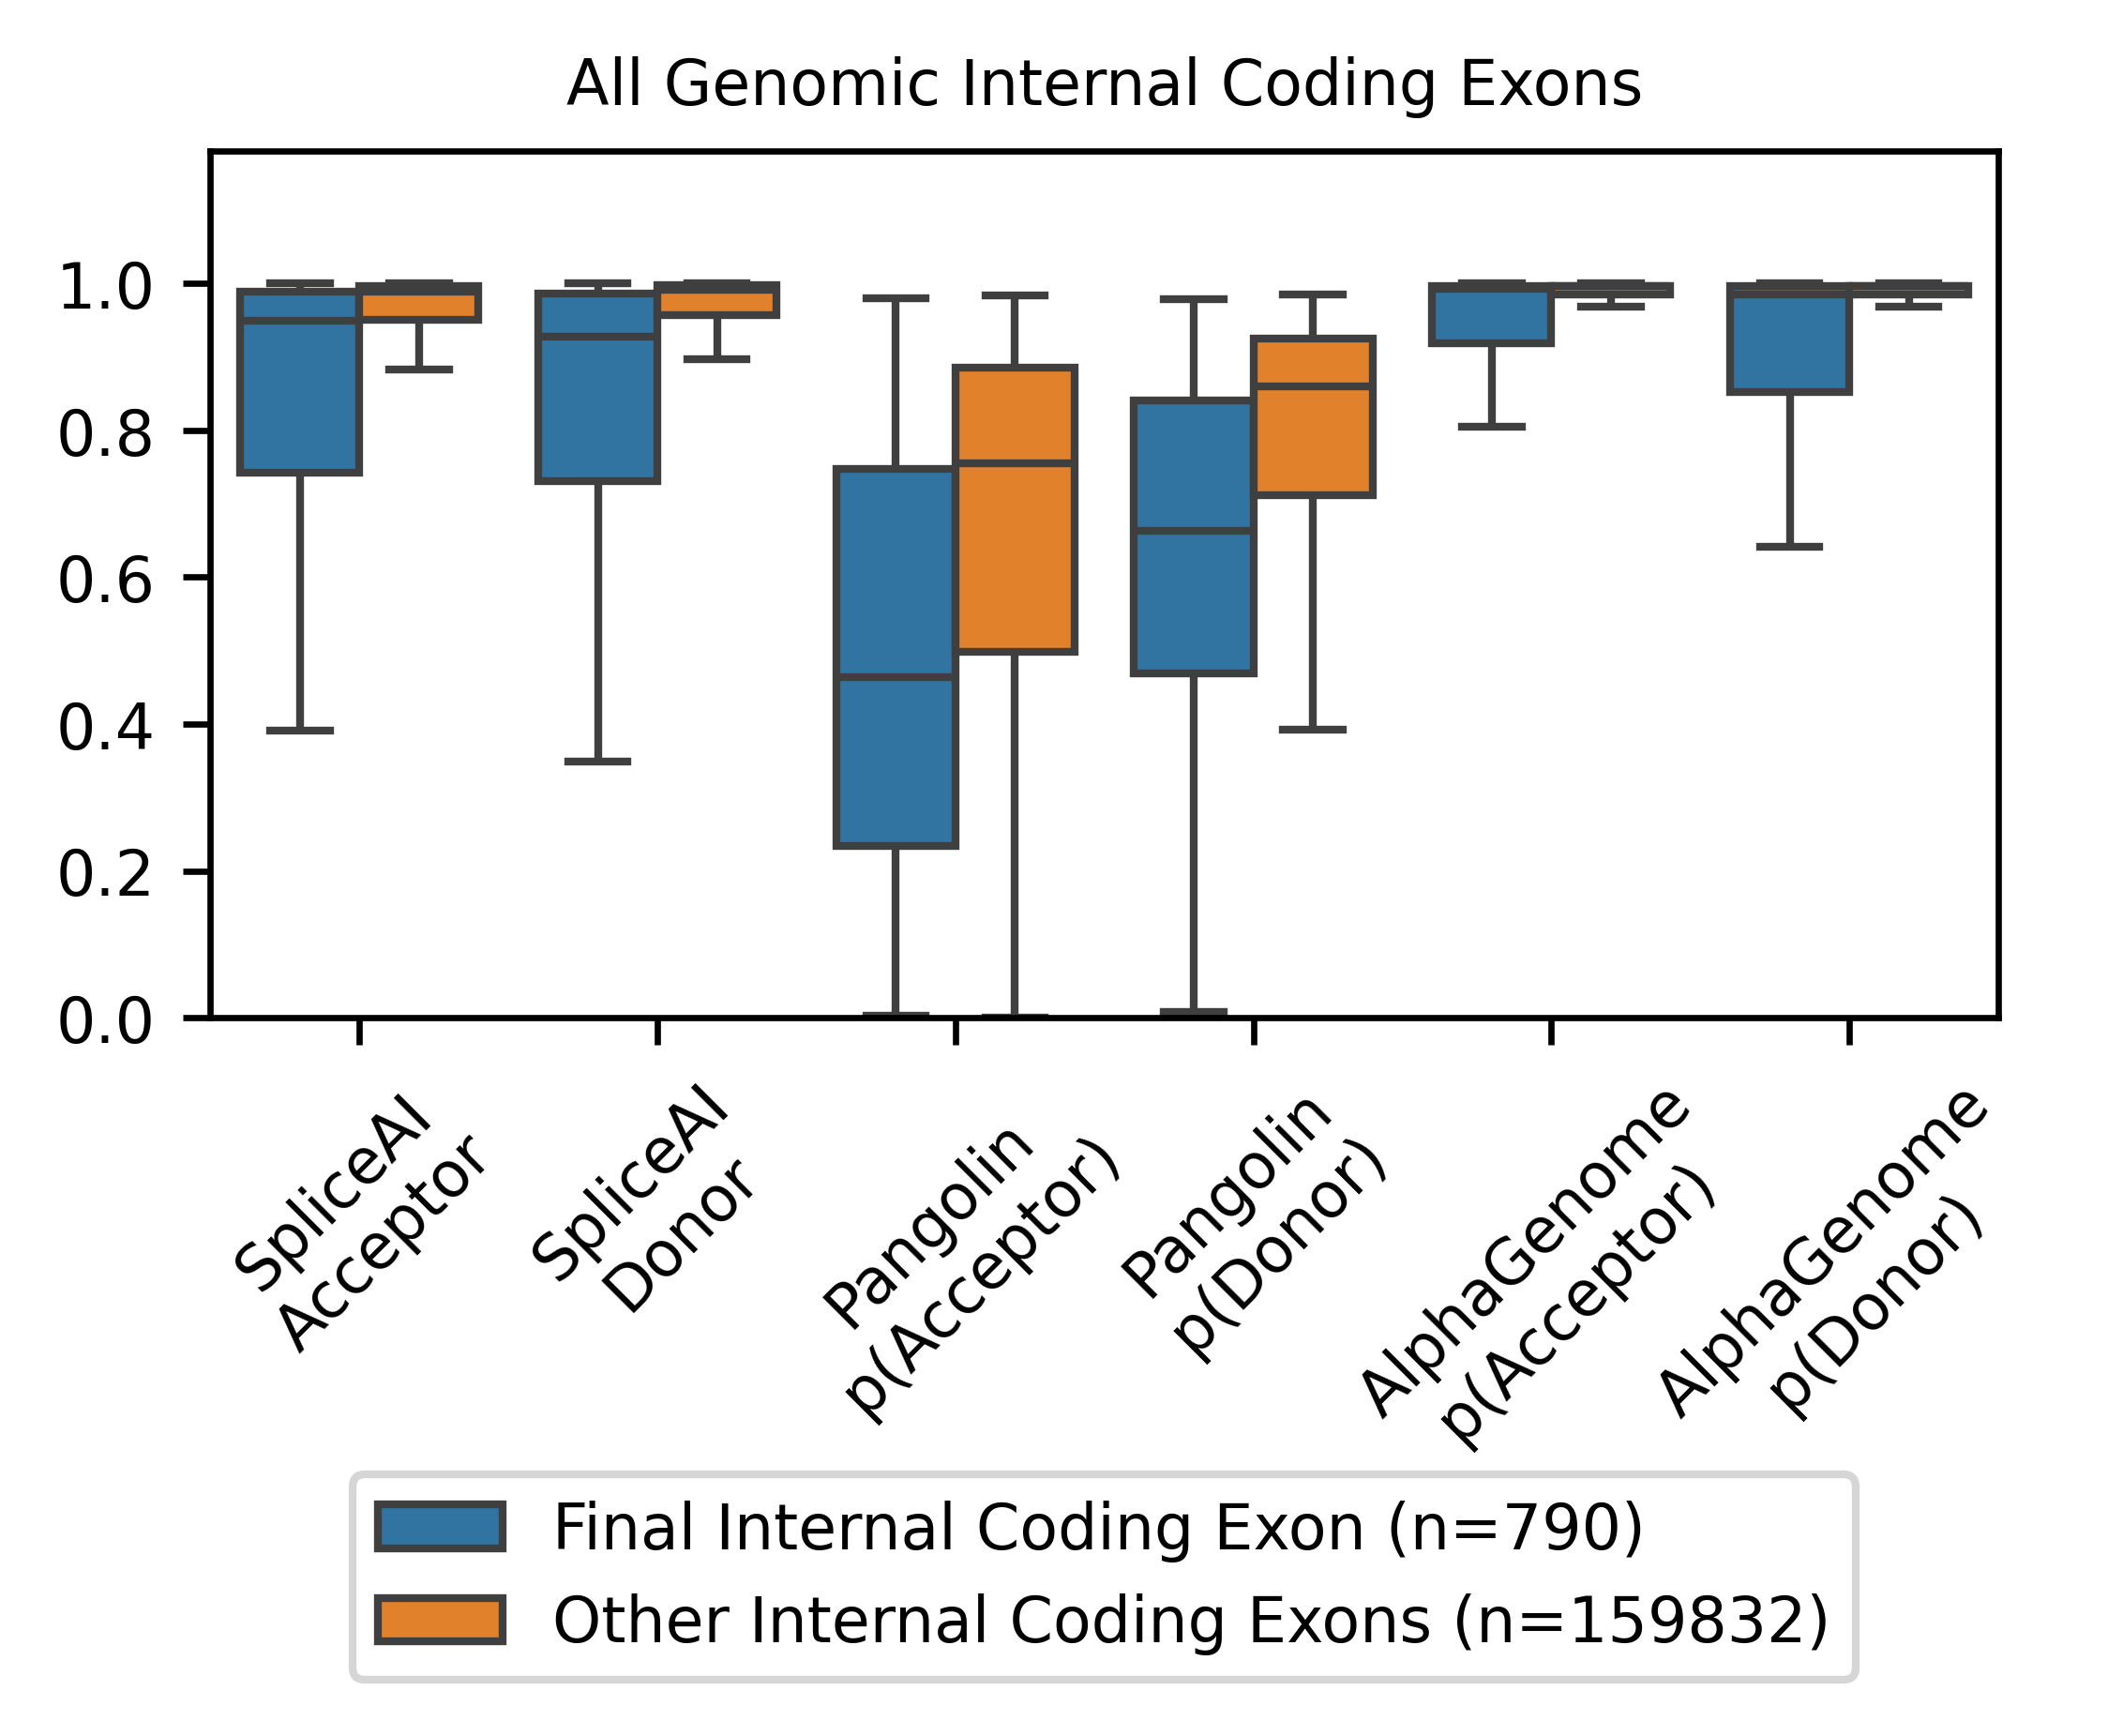

In [42]:
fig, ax = plot_utils.plot_boxplot_two_dfs(
    internal_exons_with_cds_scored_last, 
    internal_exons_with_cds_scored_notlast, 
    columns=["SpliceAI\nAcceptor", "SpliceAI\nDonor", "Pangolin\np(Acceptor)", "Pangolin\np(Donor)", "AlphaGenome\np(Acceptor)", "AlphaGenome\np(Donor)"],
    labels=("Final Internal Coding Exon", "Other Internal Coding Exons"),
    figsize=(4.1,2.0),
    dpi=600,
    bbox_to_anchor=(0.5, -0.80),
    fontsize=8
)
ax.set_title("All Genomic Internal Coding Exons", fontsize=8)
ax.set_ylim(-0.0, 1.18)

fig.show()
fig.savefig("figures/genomic_internal_coding_exon_scores.svg", bbox_inches="tight")

### Final Internal Coding Exon vs Other Exons (Constitutive)

In [43]:
cols_to_test = [
    "SpliceAI Acceptor",
    "SpliceAI Donor",
    "AlphaGenome p(Donor)",
    "AlphaGenome p(Acceptor)",
    "Pangolin p(Acceptor)",
    "Pangolin p(Donor)",
    "Pangolin Acceptor Usage",
    "Pangolin Donor Usage",
]

# Loop through columns and print the t-test results
for col in cols_to_test:
    t_stat, p_val = scipy.stats.ttest_ind(
        internal_exons_with_cds_scored_notlast_constitutive[col],
        internal_exons_with_cds_scored_last_constitutive[col],
        equal_var=False
    )
    print(f"{col}: t = {t_stat:.4f}, p = {p_val:.4e}")

SpliceAI Acceptor: t = 5.2876, p = 7.8538e-07
SpliceAI Donor: t = 5.4486, p = 3.9401e-07
AlphaGenome p(Donor): t = 5.9194, p = 5.1113e-08
AlphaGenome p(Acceptor): t = 5.2710, p = 8.4701e-07
Pangolin p(Acceptor): t = 7.6851, p = 1.3060e-11
Pangolin p(Donor): t = 7.2610, p = 9.7839e-11
Pangolin Acceptor Usage: t = 8.8392, p = 4.5375e-14
Pangolin Donor Usage: t = 8.4780, p = 2.6025e-13


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3256405570.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


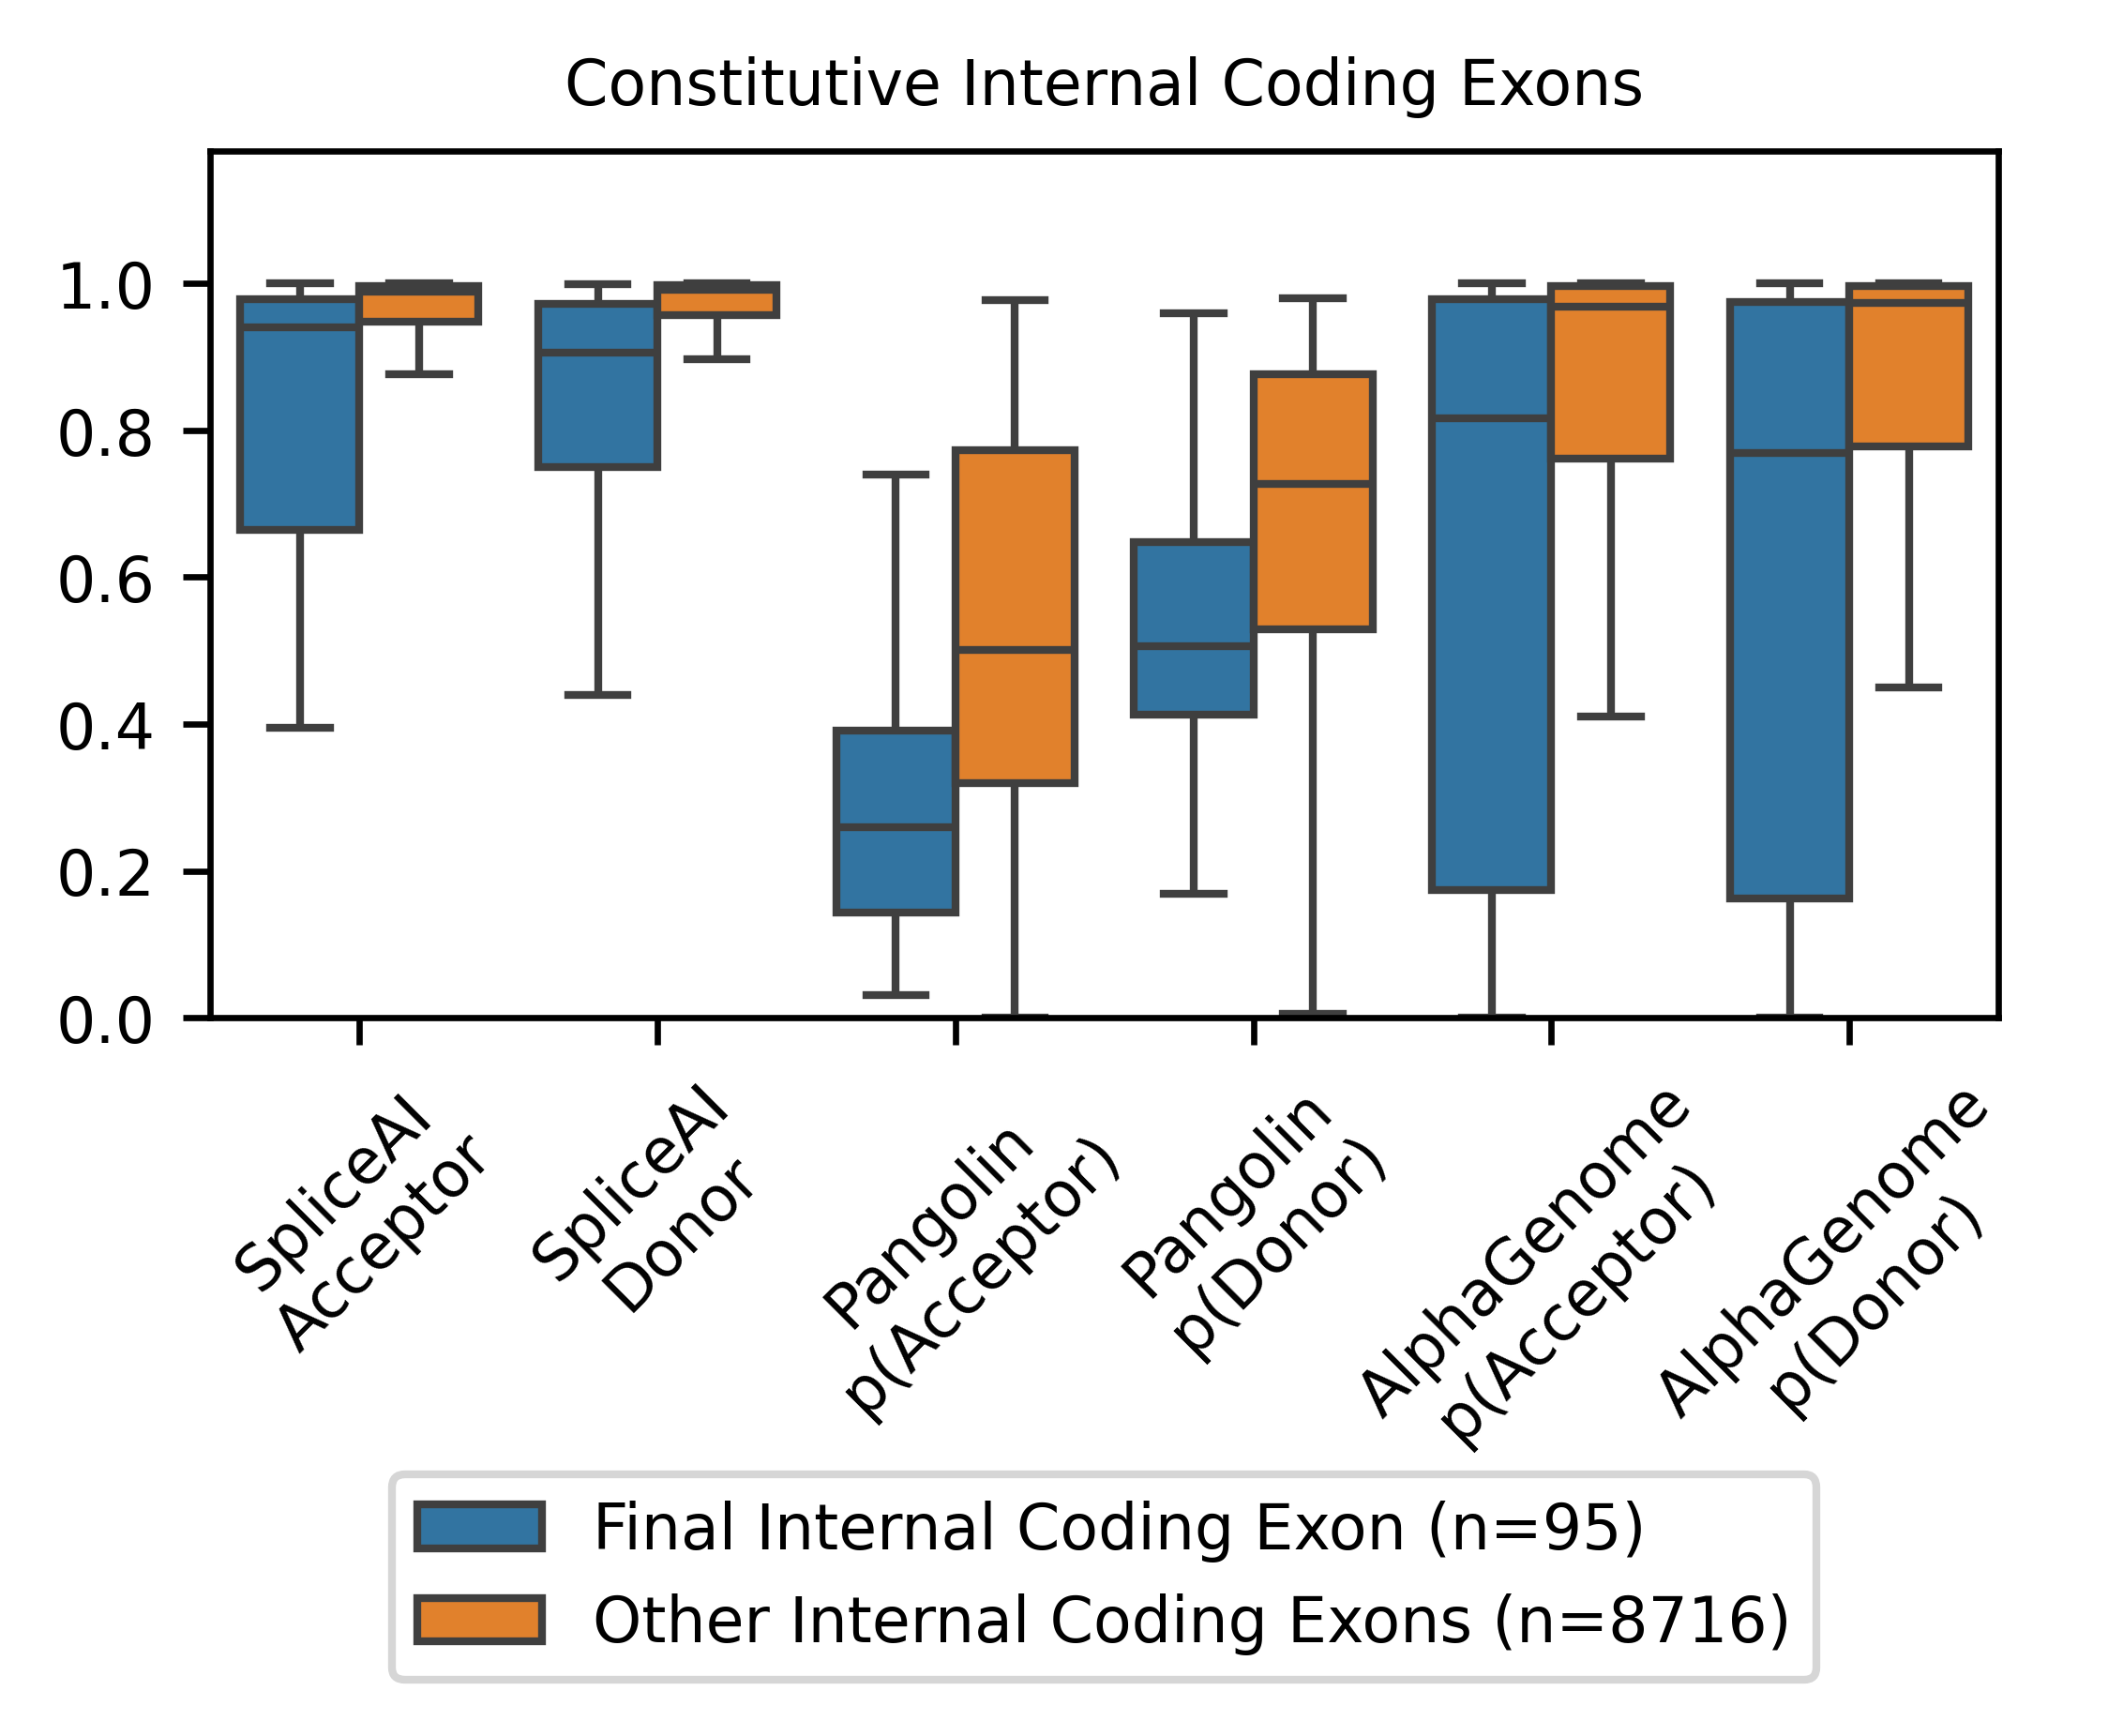

In [44]:
fig, ax = plot_utils.plot_boxplot_two_dfs(
    internal_exons_with_cds_scored_last_constitutive, 
    internal_exons_with_cds_scored_notlast_constitutive, 
    columns=["SpliceAI\nAcceptor", "SpliceAI\nDonor", "Pangolin\np(Acceptor)", "Pangolin\np(Donor)", "AlphaGenome\np(Acceptor)", "AlphaGenome\np(Donor)"],
    labels=("Final Internal Coding Exon", "Other Internal Coding Exons"),
    figsize=(4.1,2.0),
    dpi=600,
    bbox_to_anchor=(0.5, -0.80),
    fontsize=8
)
ax.set_title("Constitutive Internal Coding Exons", fontsize=8)
ax.set_ylim(-0.0, 1.18)
fig.show()

fig.savefig("figures/genomic_internal_coding_exon_constitutive_scores.svg", bbox_inches="tight")

In [45]:
def welch_tests_by_bin(df_last, df_notlast, score_col, group_col, bin_edges):
    df1 = df_last.copy()
    df1["Dataset"] = "Last"
    df2 = df_notlast.copy()
    df2["Dataset"] = "NotLast"
    df = pd.concat([df1, df2], ignore_index=True)

    df[group_col] = df[group_col].apply(
        lambda v: v[0] if isinstance(v, (list, tuple)) and len(v)==1 else v
    )
    df[group_col] = pd.to_numeric(df[group_col], errors="coerce")

    bin_edges_ext = list(bin_edges) + [df[group_col].max() + 1]
    df["bin"] = pd.cut(df[group_col], bins=bin_edges_ext, include_lowest=True, right=False)

    def bin_label(interval, last_edge=bin_edges[-1]):
        if interval.left >= last_edge:
            return f"{int(interval.left)}+"
        else:
            return f"{int(interval.left)}–{int(interval.right)}"

    df["bin_str"] = df["bin"].apply(bin_label)

    results = []
    for b in df["bin_str"].unique():
        group_df = df[df["bin_str"] == b]
        vals_last = group_df.loc[group_df["Dataset"]=="Last", score_col].dropna()
        vals_notlast = group_df.loc[group_df["Dataset"]=="NotLast", score_col].dropna()

        if len(vals_last) >= 2 and len(vals_notlast) >= 2:
            t, p = scipy.stats.ttest_ind(vals_last, vals_notlast, equal_var=False)
        else:
            t, p = np.nan, np.nan

        results.append({
            "bin": b,
            "n_last": len(vals_last),
            "n_notlast": len(vals_notlast),
            "t_stat": t,
            "p_value": p
        })

    return pd.DataFrame(results)

### Final Internal Coding Exon vs Other Exons (Binned by Exon Length)

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3168794597.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: SpliceAI Donor
       bin  n_last  n_notlast     t_stat       p_value
0  100–250     389      97570 -10.121007  1.580585e-21
1   50–100     239      44787  -7.597393  6.827454e-13
2     500+      51       3300  -3.767996  4.316227e-04
3     0–50      79       6813  -3.809146  2.744955e-04
4  250–500      32       7362  -3.306150  2.388530e-03


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3168794597.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: SpliceAI Acceptor
       bin  n_last  n_notlast    t_stat       p_value
0  100–250     389      97570 -8.684266  1.065625e-16
1   50–100     239      44787 -7.602798  6.606013e-13
2     500+      51       3300 -1.656851  1.037022e-01
3     0–50      79       6813 -3.570891  6.095568e-04
4  250–500      32       7362 -1.315794  1.978622e-01


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3168794597.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


...


Welch t-test for: AlphaGenome p(Donor)
       bin  n_last  n_notlast    t_stat       p_value
0  100–250     389      97570 -9.283508  1.176017e-18
1   50–100     239      44787 -4.953297  1.380247e-06
2     500+      51       3300 -4.039615  1.829568e-04
3     0–50      79       6813 -2.255153  2.689755e-02
4  250–500      32       7362 -1.944675  6.090648e-02


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3168794597.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: Pangolin p(Acceptor)
       bin  n_last  n_notlast     t_stat       p_value
0  100–250     389      97570 -13.346688  9.860159e-34
1   50–100     239      44787 -12.835447  4.695305e-29
2     500+      51       3300  -3.927767  2.574615e-04
3     0–50      79       6813  -3.339618  1.275868e-03
4  250–500      32       7362  -2.413515  2.185475e-02


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/3168794597.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: Pangolin p(Donor)
       bin  n_last  n_notlast     t_stat       p_value
0  100–250     389      97570 -12.941643  4.065756e-32
1   50–100     239      44787 -11.962755  3.656664e-26
2     500+      51       3300  -3.712598  5.068869e-04
3     0–50      79       6813  -3.385086  1.107113e-03
4  250–500      32       7362  -1.930068  6.272629e-02


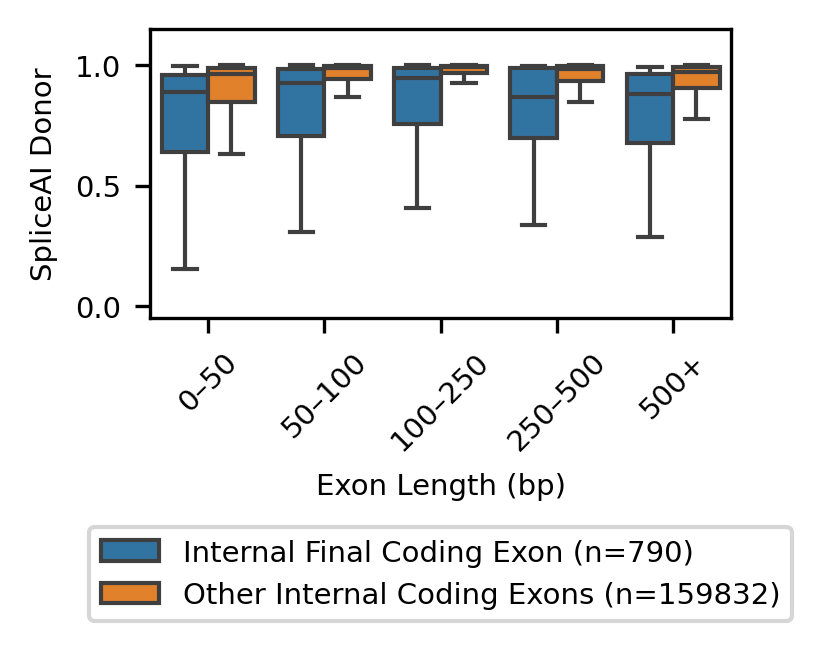

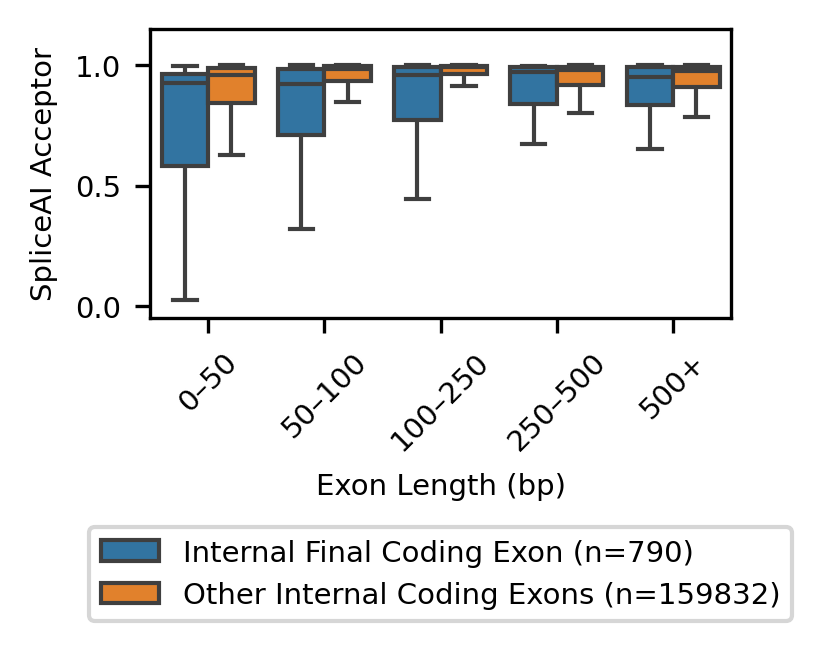

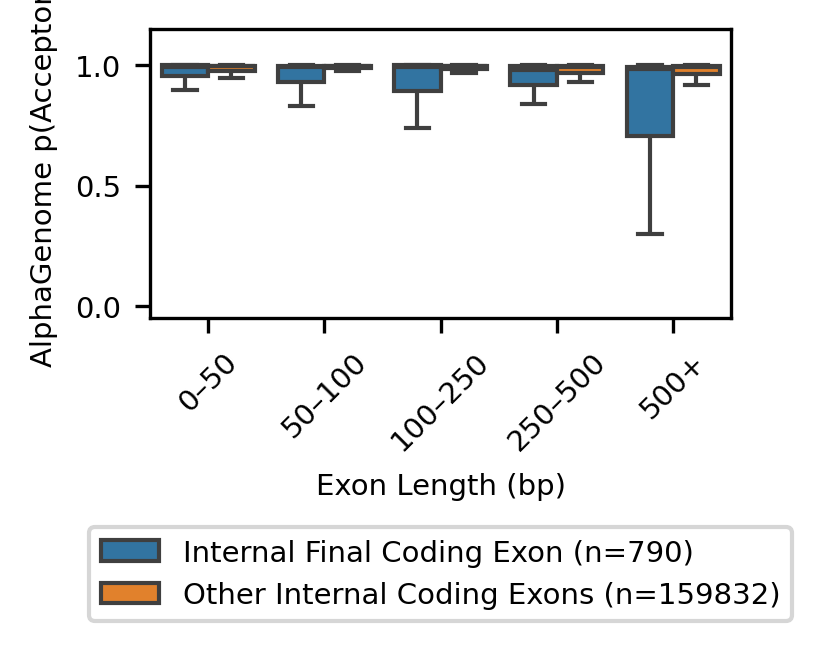

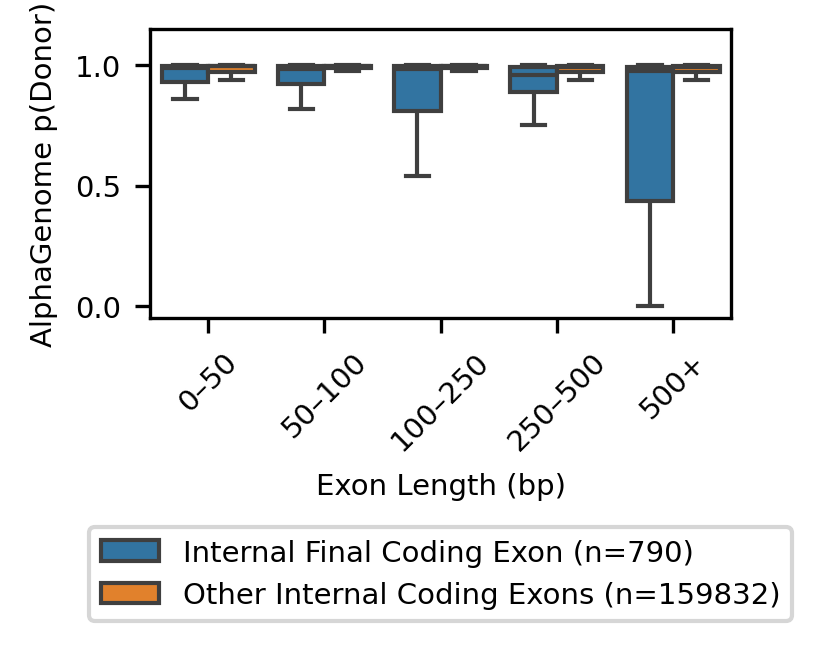

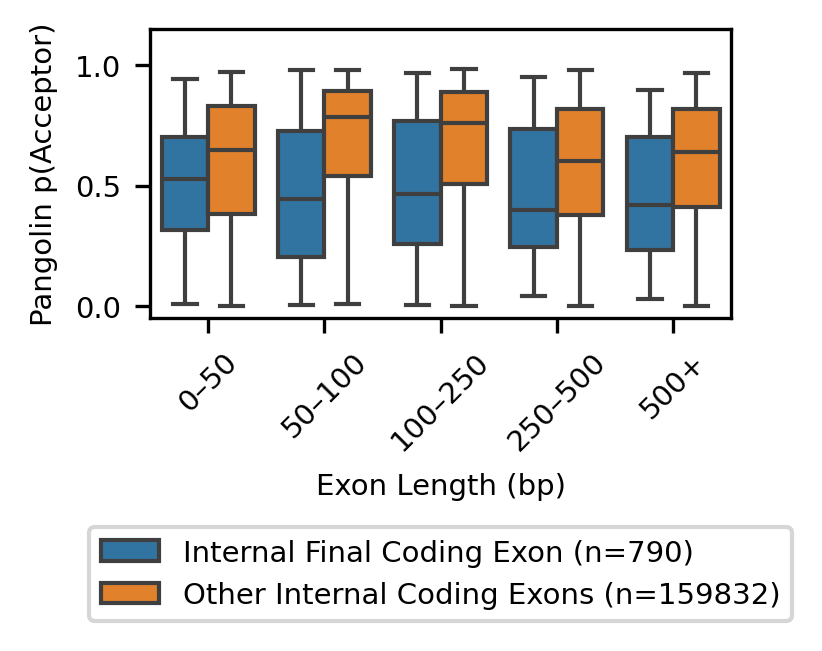

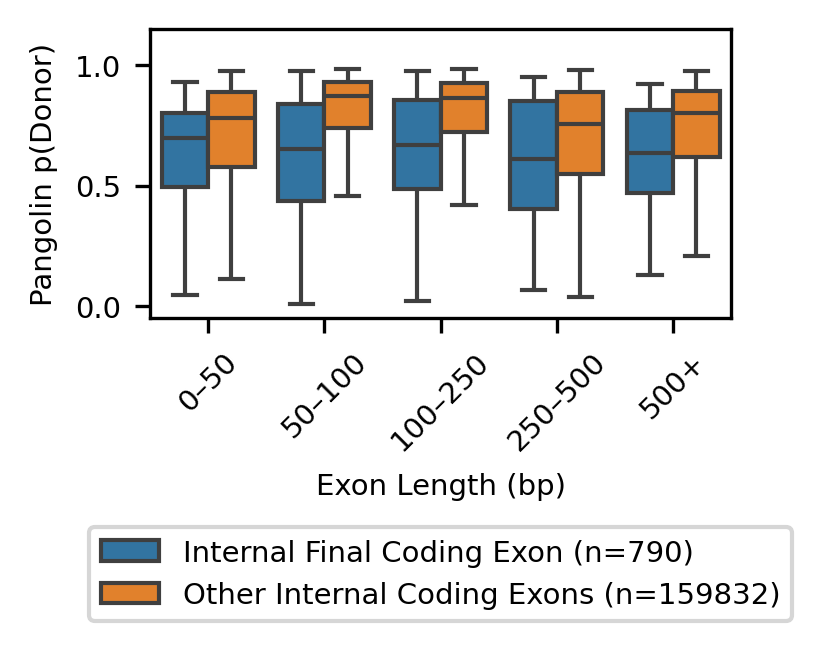

In [46]:
bin_edges = [0, 50, 100, 250, 500]

score_list = [
    "SpliceAI Donor",
    "SpliceAI Acceptor",
    "AlphaGenome p(Acceptor)",
    "AlphaGenome p(Donor)",
    "Pangolin p(Acceptor)",
    "Pangolin p(Donor)"
]

for score in score_list:
    fig, ax = plot_utils.plot_compare_two_dfs(
        internal_exons_with_cds_scored_last,
        internal_exons_with_cds_scored_notlast,
        f"Internal Final Coding Exon (n={len(internal_exons_with_cds_scored_last)})",
        f"Other Internal Coding Exons (n={len(internal_exons_with_cds_scored_notlast)})",
        score_col=score,
        group_col="exon_length",
        bin_edges=bin_edges,
        score_label=score,
        group_label="Exon Length (bp)",
        figsize=(2.5, 1.25),
        bbox_to_anchor=(0.5, -1.1),
        ylim=(-0.05, 1.15)
    )
    fig.show()

    fig.savefig(f"figures/genomic_internal_coding_exon_{score}_length.svg", bbox_inches="tight")

    stats_df = welch_tests_by_bin(
        internal_exons_with_cds_scored_last,
        internal_exons_with_cds_scored_notlast,
        score_col=score,
        group_col="exon_length",
        bin_edges=bin_edges
    )
    print(f"\nWelch t-test for: {score}")
    print(stats_df)

### Final Internal Coding Exon vs Other Exons (Binned by Exon Rank)

/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1799798857.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: SpliceAI Donor
     bin  n_last  n_notlast    t_stat       p_value
0  10–20     219      43021 -8.749846  5.836377e-16
1   0–10     455      91027 -9.864712  6.211573e-21
2    30+      40      11651 -4.232119  1.356364e-04
3  20–30      76      14133 -5.095313  2.511150e-06


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1799798857.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: SpliceAI Acceptor
     bin  n_last  n_notlast    t_stat       p_value
0  10–20     219      43021 -7.435424  2.339099e-12
1   0–10     455      91027 -8.462376  3.603630e-16
2    30+      40      11651 -3.659329  7.458798e-04
3  20–30      76      14133 -4.779301  8.528654e-06


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1799798857.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


...


Welch t-test for: AlphaGenome p(Donor)
     bin  n_last  n_notlast     t_stat       p_value
0  10–20     219      43021  -4.312807  2.439542e-05
1   0–10     455      91027 -10.889296  1.072231e-24
2    30+      40      11651  -2.009814  5.137190e-02
3  20–30      76      14133  -2.330482  2.246178e-02


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1799798857.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: Pangolin p(Acceptor)
     bin  n_last  n_notlast     t_stat       p_value
0  10–20     219      43021 -11.063704  6.717892e-23
1   0–10     455      91027 -15.286947  6.468972e-43
2    30+      40      11651  -4.697034  3.209013e-05
3  20–30      76      14133  -4.937836  4.607241e-06


/var/folders/vg/d_4ndfrn7615qk6kxwxnqdl80000gn/T/ipykernel_58942/1799798857.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



Welch t-test for: Pangolin p(Donor)
     bin  n_last  n_notlast     t_stat       p_value
0  10–20     219      43021 -10.455313  5.134593e-21
1   0–10     455      91027 -14.568752  9.156873e-40
2    30+      40      11651  -3.822329  4.611987e-04
3  20–30      76      14133  -5.257078  1.321699e-06


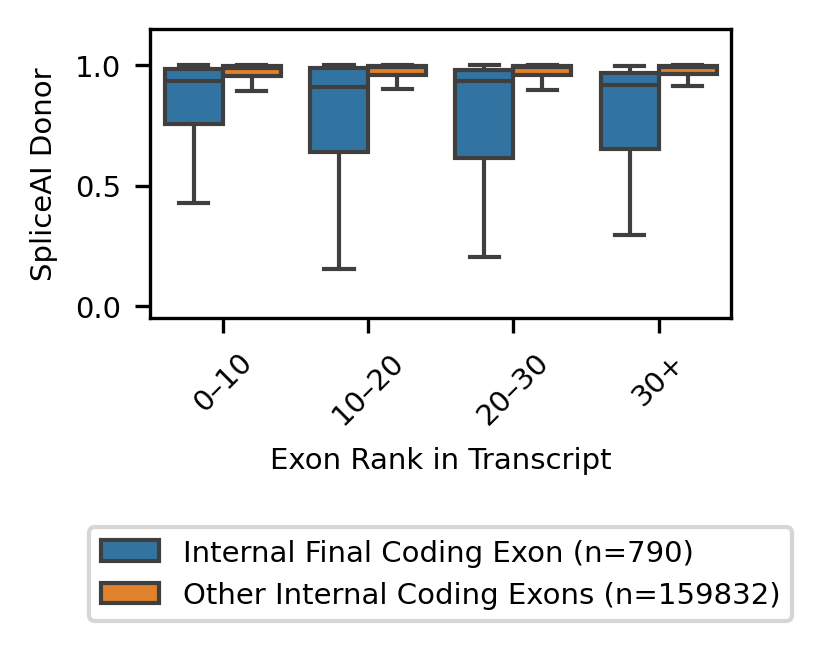

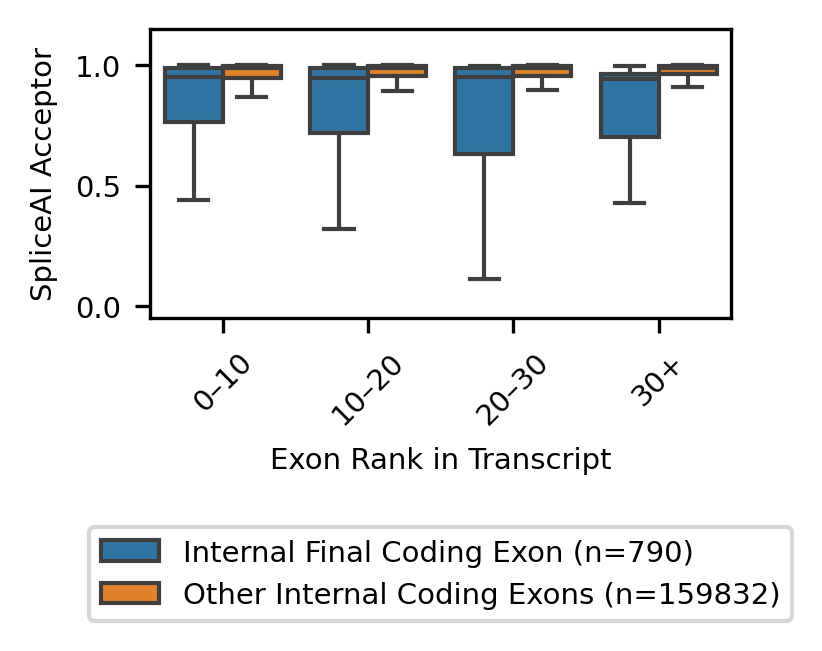

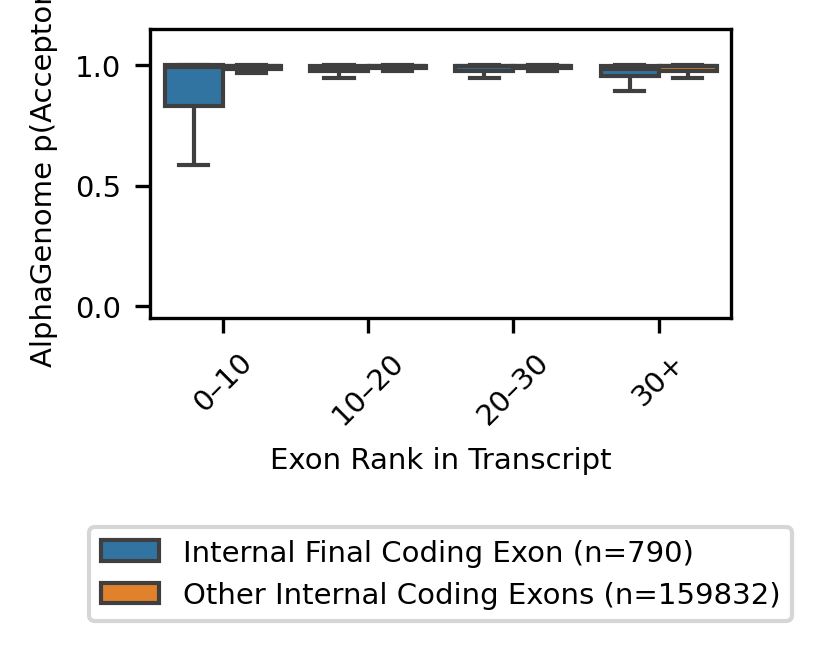

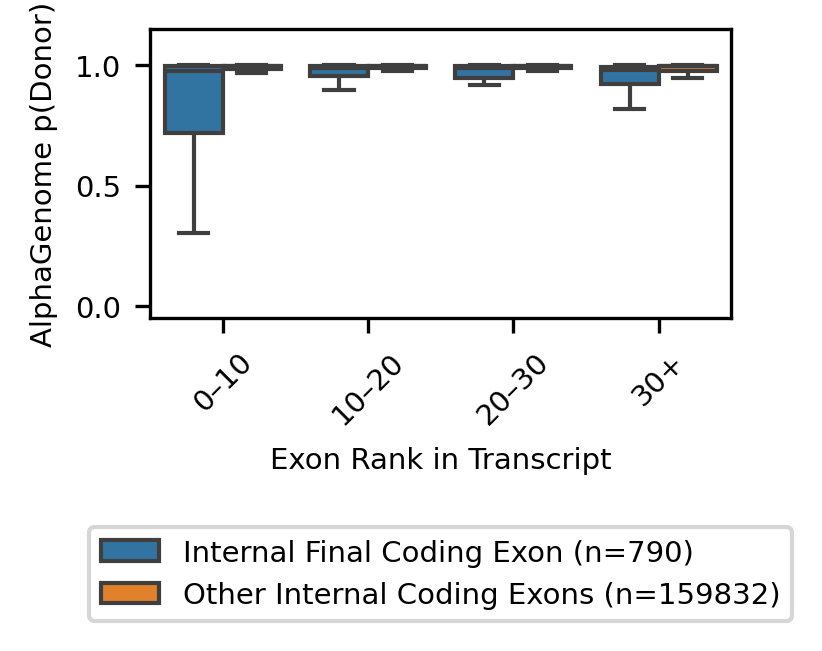

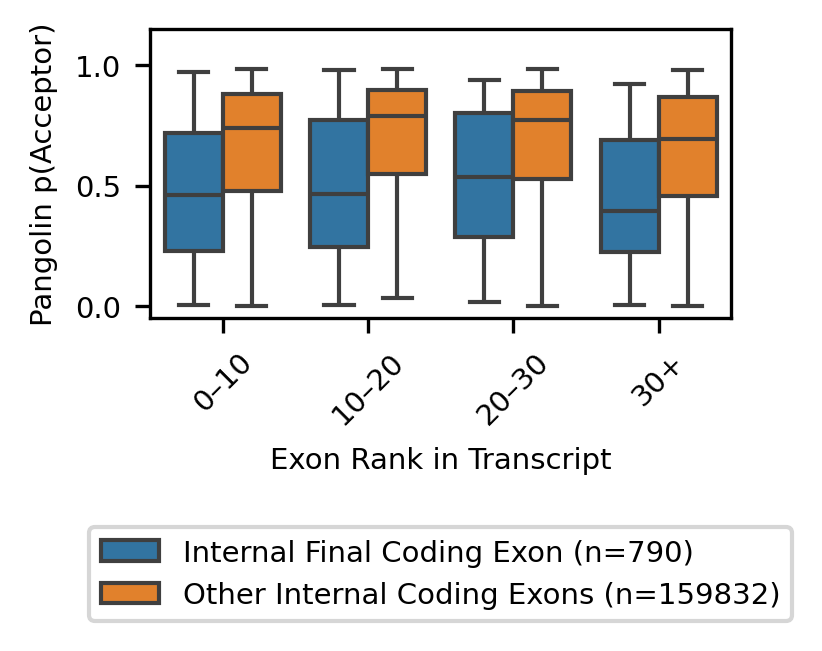

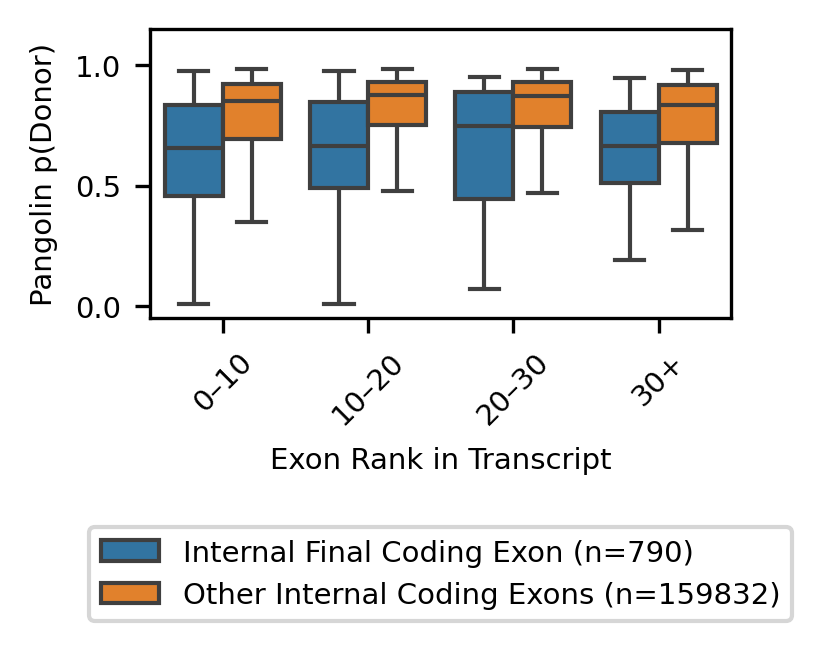

In [47]:
bin_edges = [0, 10, 20, 30]

score_list = [
    "SpliceAI Donor",
    "SpliceAI Acceptor",
    "AlphaGenome p(Acceptor)",
    "AlphaGenome p(Donor)",
    "Pangolin p(Acceptor)",
    "Pangolin p(Donor)"
]

for score in score_list:
    fig, ax = plot_utils.plot_compare_two_dfs(
        internal_exons_with_cds_scored_last,
        internal_exons_with_cds_scored_notlast,
        f"Internal Final Coding Exon (n={len(internal_exons_with_cds_scored_last)})",
        f"Other Internal Coding Exons (n={len(internal_exons_with_cds_scored_notlast)})",
        score_col=score,
        group_col="first_exon_rank",
        bin_edges=bin_edges,
        score_label=score,
        group_label="Exon Rank in Transcript",
        figsize=(2.5, 1.25),
        bbox_to_anchor=(0.5, -1.10),
        ylim=(-0.05, 1.15)
    )
    fig.show()

    fig.savefig(f"figures/genomic_internal_coding_exon_{score}_rank.svg", bbox_inches="tight")

    stats_df = welch_tests_by_bin(
        internal_exons_with_cds_scored_last,
        internal_exons_with_cds_scored_notlast,
        score_col=score,
        group_col="first_exon_rank",
        bin_edges=bin_edges
    )
    print(f"\nWelch t-test for: {score}")
    print(stats_df)